In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error, mean_squared_error
import joblib


In [3]:
df = pd.read_csv("metro_crowd_data.csv")
df.head()

,station_id,time_of_day,day_of_week,is_holiday,weather,nearby_events,temperature,platform_capacity,crowd_level
0,7,20,3,1,Sunny,0,40.0,500,Medium
1,20,11,5,0,Sunny,0,31.1,900,Medium
2,15,8,2,0,Sunny,0,22.1,300,Medium
3,11,0,1,0,Sunny,1,28.5,900,Medium
4,8,17,3,0,Sunny,0,31.9,900,Low


In [4]:
print("Shape:", df.shape)
display(df.describe(include='all'))
display(df.dtypes.value_counts())

if 'crowd_level' in df.columns:
    print("\nTarget distribution:")
    display(df['crowd_level'].value_counts(normalize=True))


Shape: (2500, 9)


,station_id,time_of_day,day_of_week,is_holiday,weather,nearby_events,temperature,platform_capacity,crowd_level
count,2500.000000,2500.000000,2500.000000,2500.000000,2500,2500.000000,2500.000000,2500.000000,2500
unique,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Sunny,NaN,NaN,NaN,High
freq,NaN,NaN,NaN,NaN,1558,NaN,NaN,NaN,850
mean,10.368000,11.726400,3.029200,0.082800,NaN,0.403600,30.028320,604.800000,NaN
std,5.822485,6.936829,2.004883,0.275635,NaN,0.634404,4.955484,224.100532,NaN
min,1.000000,0.000000,0.000000,0.000000,NaN,0.000000,13.100000,300.000000,NaN
25%,5.000000,6.000000,1.000000,0.000000,NaN,0.000000,26.800000,500.000000,NaN
50%,10.000000,12.000000,3.000000,0.000000,NaN,0.000000,30.000000,700.000000,NaN
75%,15.000000,18.000000,5.000000,0.000000,NaN,1.000000,33.225000,900.000000,NaN


int64      6
object     2
float64    1
Name: count, dtype: int64


Target distribution:


crowd_level
High      0.3400
Low       0.3312
Medium    0.3288
Name: proportion, dtype: float64

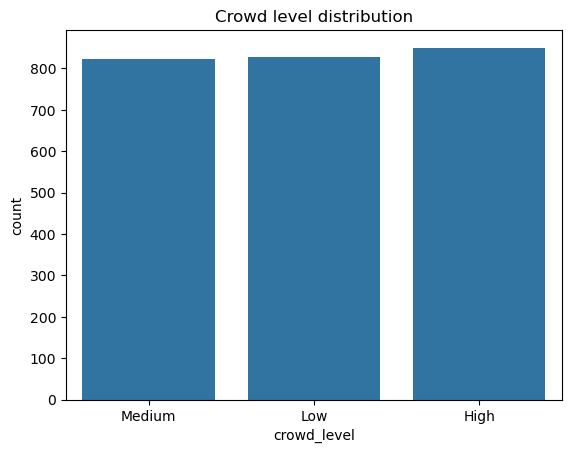

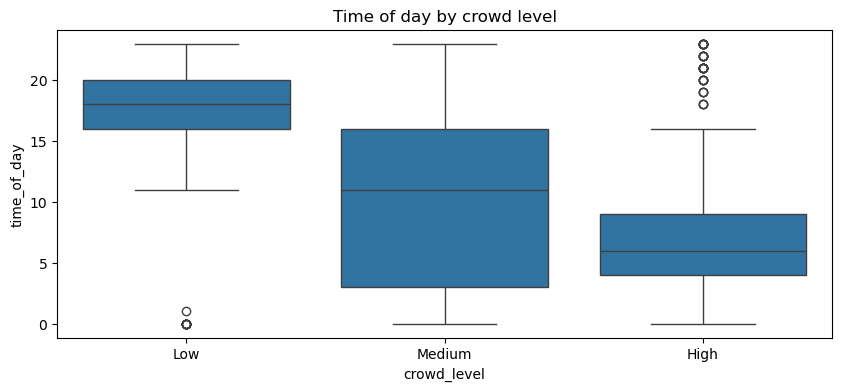

In [5]:
if 'crowd_level' in df.columns:
    sns.countplot(data=df, x='crowd_level')
    plt.title('Crowd level distribution')
    plt.show()
    
if 'time_of_day' in df.columns and 'crowd_level' in df.columns:
    plt.figure(figsize=(10,4))
    sns.boxplot(x='crowd_level', y='time_of_day', data=df, order=['Low','Medium','High'])
    plt.title('Time of day by crowd level')
    plt.show()


In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

TARGET = 'crowd_level' if 'crowd_level' in df.columns else 'target'
y = df[TARGET]
X = df.drop(columns=[TARGET])

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop')

X_pre = preprocessor.fit_transform(X)
print("Transformed feature matrix shape:", X_pre.shape)


Transformed feature matrix shape: (2500, 10)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)


(2000, 8) (500, 8)


In [8]:
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', clf)
])

pipeline.fit(X_train, y_train)
print("Training complete.")


Training complete.


In [9]:
clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('clf', clf)
])

pipeline.fit(X_train, y_train)
print("Training complete.")


Training complete.


Accuracy: 0.942

Classification report:
               precision    recall  f1-score   support

        High       0.95      0.95      0.95       170
         Low       0.96      0.97      0.96       166
      Medium       0.92      0.90      0.91       164

    accuracy                           0.94       500
   macro avg       0.94      0.94      0.94       500
weighted avg       0.94      0.94      0.94       500



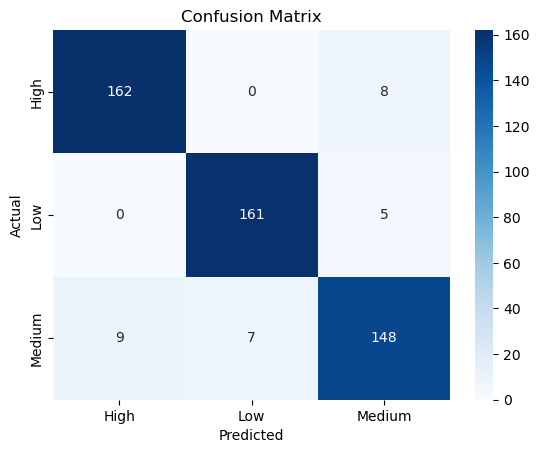

In [10]:
y_pred = pipeline.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix'); plt.show()


In [11]:
scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print("5-fold CV accuracy:", scores, "mean:", scores.mean()*100)


5-fold CV accuracy: [0.934 0.93  0.94  0.912 0.918] mean: 92.68


In [12]:
model_path = "metrolink_model.joblib"
joblib.dump(pipeline, model_path)
print("Saved model to", model_path)


Saved model to metrolink_model.joblib


In [13]:
sample = X_test.iloc[[0]]
pred = pipeline.predict(sample)
prob = pipeline.predict_proba(sample) if hasattr(pipeline, "predict_proba") else None
print("Sample input:\n", sample)
print("Predicted:", pred, "Prob:", prob)


Sample input:
      station_id  time_of_day  day_of_week  is_holiday weather  nearby_events  \
143           1           12            4           0  Cloudy              0   

     temperature  platform_capacity  
143         27.4                900  
Predicted: ['Medium'] Prob: [[0.255 0.09  0.655]]


In [ ]:
import pandas as pd
import joblib

model = joblib.load("metrolink_model.joblib")

sample = pd.DataFrame([{
    'station_id': 3,
    'time_of_day': 10,         
    'day_of_week': 2,        
    'is_holiday': 0,            
    'nearby_events': 0,         
    'temperature': 29.5,        
    'platform_capacity': 500,     
    'weather': 'Clear'          
}])


prediction = model.predict(sample)

print("🚆 Predicted Metro Crowd Level:", prediction[0])


🚆 Predicted Metro Crowd Level: Medium


In [ ]:
!pip install ipywidgets


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [16]:
!jupyter nbextension enable --py widgetsnbextension


usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: console dejavu events execute kernel kernelspec lab
labextension labhub migrate nbconvert notebook qtconsole run server
troubleshoot trust

Jupyter command `jupyter-nbextension` not found.


In [22]:
import ipywidgets as widgets
from IPython.display import display



station_id = widgets.IntSlider(value=3, min=1, max=20, description='Station ID:')
time_of_day = widgets.IntSlider(value=10, min=0, max=23, description='Hour (0–23):')
day_of_week = widgets.IntSlider(value=2, min=0, max=6, description='Day (0=Mon):')
is_holiday = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description='Holiday:')
nearby_events = widgets.Dropdown(options=[('None', 0), ('Yes', 1)], description='Events:')
temperature = widgets.FloatSlider(value=30.0, min=10, max=45, description='Temp (°C):')
platform_capacity = widgets.IntSlider(value=500, min=300, max=900)
weather = widgets.Dropdown(options=['Sunny', 'Cloudy', 'Rainy'], description='Weather:')

output = widgets.Output()

def predict_crowd(b):
    with output:
        output.clear_output()
        sample = pd.DataFrame([{
            'station_id': station_id.value,
            'time_of_day': time_of_day.value,
            'day_of_week': day_of_week.value,
            'is_holiday': is_holiday.value,
            'nearby_events': nearby_events.value,
            'temperature': temperature.value,
            'platform_capacity': platform_capacity.value,
            'weather': weather.value
        }])
        pred = model.predict(sample)
        print(f"🚇 Estimated Crowd Level: {pred[0]}")


button = widgets.Button(description="Predict Crowd Level 🚦", button_style='success')
button.on_click(predict_crowd)


display(station_id, time_of_day, day_of_week, is_holiday, nearby_events,
        temperature, platform_capacity, weather, button, output)


IntSlider(value=3, description='Station ID:', max=20, min=1)

IntSlider(value=10, description='Hour (0–23):', max=23)

IntSlider(value=2, description='Day (0=Mon):', max=6)

Dropdown(description='Holiday:', options=(('No', 0), ('Yes', 1)), value=0)

Dropdown(description='Events:', options=(('None', 0), ('Yes', 1)), value=0)

FloatSlider(value=30.0, description='Temp (°C):', max=45.0, min=10.0)

IntSlider(value=500, max=900, min=300)

Dropdown(description='Weather:', options=('Sunny', 'Cloudy', 'Rainy'), value='Sunny')

Button(button_style='success', description='Predict Crowd Level 🚦', style=ButtonStyle())

Output()

In [20]:
from IPython.display import display, HTML



In [21]:
display(HTML("""
<div style="
    background: linear-gradient(135deg, #0077b6, #00b4d8);
    color: white;
    padding: 20px;
    border-radius: 12px;
    text-align: center;
    margin-bottom: 20px;
    box-shadow: 0 4px 10px rgba(0,0,0,0.2);
">
  <h1 style="font-size: 28px; margin: 0;">🚇 MetroLink – Real-time Crowd Estimation</h1>
  <p style="font-size: 16px; margin-top: 10px;">Interactive Machine Learning Prototype</p>
</div>
"""))


station_id = widgets.IntSlider(value=3, min=1, max=20, description='Station ID:')
time_of_day = widgets.IntSlider(value=10, min=0, max=23, description='Hour (0–23):')
day_of_week = widgets.IntSlider(value=2, min=0, max=6, description='Day (0=Mon):')
is_holiday = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], description='Holiday:')
nearby_events = widgets.Dropdown(options=[('None', 0), ('Yes', 1)], description='Events:')
temperature = widgets.FloatSlider(value=30.0, min=10, max=45, description='Temp (°C):')
platform_capacity = widgets.IntSlider(value=500, min=300, max=900)
weather = widgets.Dropdown(options=[['Sunny', 'Cloudy', 'Rainy']], description='Weather:')


output = widgets.Output()


def predict_crowd(b):
    with output:
        output.clear_output()
        sample = pd.DataFrame([{
            'station_id': station_id.value,
            'time_of_day': time_of_day.value,
            'day_of_week': day_of_week.value,
            'is_holiday': is_holiday.value,
            'nearby_events': nearby_events.value,
            'temperature': temperature.value,
            'platform_capacity': platform_capacity.value,
            'weather': weather.value
        }])
        pred = model.predict(sample)[0]
        
       
        display(HTML(f"""
        <div style="
            margin-top: 20px;
            padding: 20px;
            border-radius: 12px;
            background: #caf0f8;
            color: #03045e;
            text-align: center;
            font-size: 22px;
            font-weight: bold;
            box-shadow: 0 2px 8px rgba(0,0,0,0.15);
        ">
          🚦 Estimated Crowd Level: <span style="color:#0077b6;">{pred}</span>
        </div>
        """))

button = widgets.Button(
    description="Predict Crowd Level 🚦",
    button_style='success',
    layout=widgets.Layout(width='50%', margin='20px auto')
)
button.on_click(predict_crowd)

ui = widgets.VBox([
    widgets.HBox([station_id, time_of_day]),
    widgets.HBox([day_of_week, is_holiday]),
    widgets.HBox([nearby_events, temperature]),
    widgets.HBox([platform_capacity, weather]),
    button,
    output
])

display(ui)
